In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import binom, norm
import math
from scipy import stats
import boto3
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from copy import deepcopy

In [3]:
s3 = boto3.client("s3")

response = s3.list_objects_v2(
    Bucket="data-personalprojects"
)

for obj in response.get("Contents", []):
    print(obj["Key"], obj["Size"])

housepricing/ 0
housepricing/house-prices-advanced-regression-techniques/data_description.txt 13370
housepricing/house-prices-advanced-regression-techniques/sample_submission.csv 31939
housepricing/house-prices-advanced-regression-techniques/test.csv 451405
housepricing/house-prices-advanced-regression-techniques/train.csv 460676


In [4]:
PATH = 's3://data-personalprojects/housepricing/house-prices-advanced-regression-techniques/train.csv'

df_raw = pd.read_csv(PATH)
df_raw_e = pd.read_csv(PATH)

df_raw.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


# Basic info

In [5]:
df = df_raw.copy()
df_e = df_raw_e.copy()

In [6]:
print(df.shape)
print("==="*13)
print(df.isna().sum()[df.isna().sum()>0])
print("==="*13)
print(df.select_dtypes(exclude=['str','object']).info())
print("==="*13)
print(df.columns)

(1460, 81)
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   OverallQual    1460 non-null   int64  
 5   OverallCond    1460 non-null   int64  
 6   YearBuilt      1460 non-null   int64  
 7   YearRemodAdd   1460 non-null   int64  
 8   MasVnrArea     1452 non-null   float

In [7]:
columnas_fecha = [
    "YearBuilt",
    "YearRemodAdd",
    "GarageYrBlt",
    "YrSold",
    "MoSold",
]

print(df[columnas_fecha].sample(5))
print(df[columnas_fecha].info())

      YearBuilt  YearRemodAdd  GarageYrBlt  YrSold  MoSold
1452       2005          2005       2005.0    2006       5
425        1946          1992       1947.0    2009       9
638        1910          1950          NaN    2008       5
299        1950          2004       1950.0    2009       8
155        1924          1950          NaN    2008       4
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   YearBuilt     1460 non-null   int64  
 1   YearRemodAdd  1460 non-null   int64  
 2   GarageYrBlt   1379 non-null   float64
 3   YrSold        1460 non-null   int64  
 4   MoSold        1460 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 57.2 KB
None


# Nan values

## Numerical NAN features

In [8]:
df_num = df.select_dtypes(exclude=["object", "category"]).copy()
cols_na_num = df_num.columns[df_num.isna().any()].tolist()

df[cols_na_num].isna().sum()

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [9]:
df[cols_na_num].describe()

,LotFrontage,MasVnrArea,GarageYrBlt
count,1201.000000,1452.000000,1379.000000
mean,70.049958,103.685262,1978.506164
std,24.284752,181.066207,24.689725
min,21.000000,0.000000,1900.000000
25%,59.000000,0.000000,1961.000000
50%,69.000000,0.000000,1980.000000
75%,80.000000,166.000000,2002.000000
max,313.000000,1600.000000,2010.000000


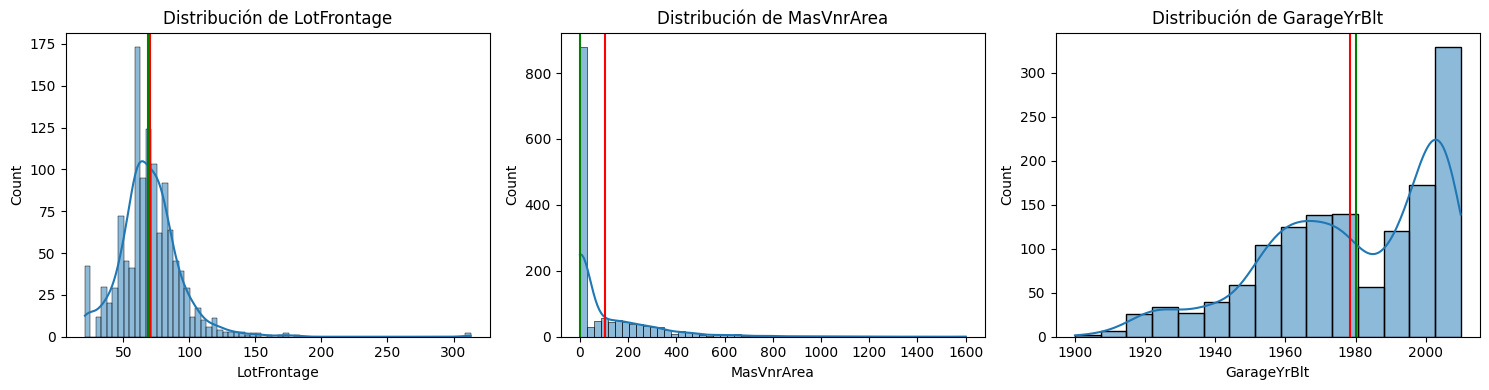

In [10]:
# 1. Definir columnas y configuración de la cuadrícula
columnas = cols_na_num
n_cols = 3  
n_filas = math.ceil(len(columnas) / n_cols)  

# 2. Crear la figura y los ejes
fig, axes = plt.subplots(n_filas, n_cols, figsize=(15, n_filas * 4))
axes = axes.flatten()  

# 3. Dibujar cada histograma en su respectivo ax
for i, col in enumerate(columnas):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].axvline(df[col].mean(),c="r")
    axes[i].axvline(df[col].median(),c="g") 
    axes[i].set_title(f"Distribución de {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  
plt.show()


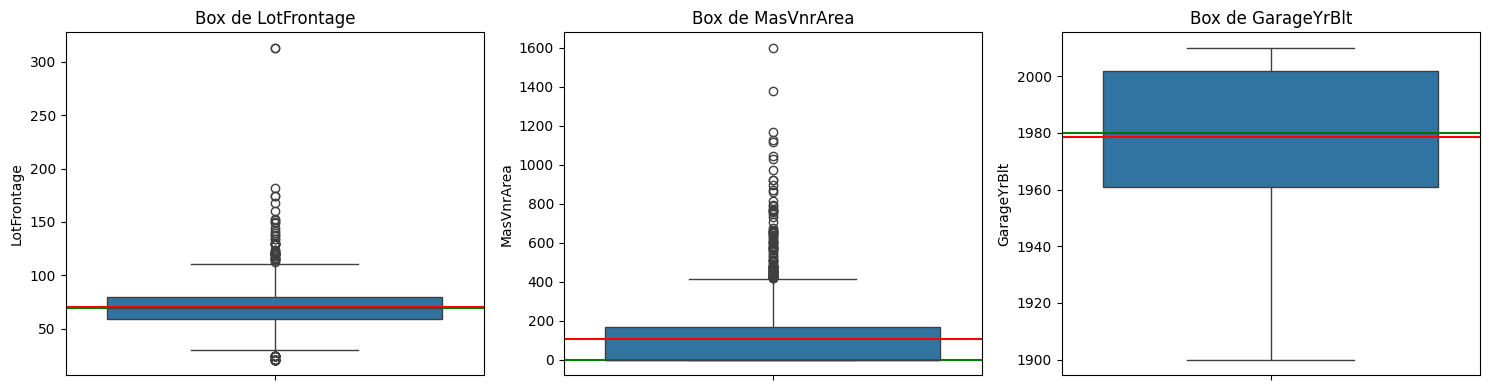

In [11]:
# 1. Definir columnas y configuración de la cuadrícula
columnas = cols_na_num
n_cols = 3  
n_filas = math.ceil(len(columnas) / n_cols)  

# 2. Crear la figura y los ejes
fig, axes = plt.subplots(n_filas, n_cols, figsize=(15, n_filas * 4))
axes = axes.flatten()  

# 3. Dibujar cada box en su respectivo ax
for i, col in enumerate(columnas):
    sns.boxplot(df[col], ax=axes[i]) 
    axes[i].axhline(df[col].mean(),c="r")
    axes[i].axhline(df[col].median(),c="g") 
    axes[i].set_title(f"Box de {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  
plt.show()


In [12]:
# Calcular métricas solo para las columnas con faltantes
analisis_df = df[cols_na_num].agg(["skew", "kurt"]).T
analisis_df.columns = ["Skewness", "Kurtosis"]

# Mostrar la tabla formateada
print(analisis_df)

             Skewness   Kurtosis
LotFrontage  2.163569  17.452867
MasVnrArea   2.669084  10.082417
GarageYrBlt -0.649415  -0.418341


In [13]:
# 1. Flag de missing
df['GarageYrBlt_flag'] = df['GarageYrBlt'].isnull().astype(int)

tab = pd.crosstab(df['GarageYrBlt_flag'], df['GarageType'].fillna('Missing'))
chi2, p, _, _ = stats.chi2_contingency(tab)
print(f"chi2: {chi2:.4f}, p-value: {p:.4f}")

chi2: 1460.0000, p-value: 0.0000


In [14]:
# 1. Flag de missing
df['MasVnrArea_flag'] = df['MasVnrArea'].isnull().astype(int)

tab = pd.crosstab(df['MasVnrArea_flag'], df['MasVnrType'].fillna('Missing'))
chi2, p, _, _ = stats.chi2_contingency(tab)
print(f"chi2: {chi2:.4f}, p-value: {p:.4f}")

chi2: 5.4242, p-value: 0.1432


In [15]:
# 1. Flag de missing
df['LotFrontage_flag'] = df['LotFrontage'].isnull().astype(int)

tab = pd.crosstab(df['LotFrontage_flag'], df['Neighborhood'].fillna('Missing'))
chi2, p, _, _ = stats.chi2_contingency(tab)
print(f"chi2: {chi2:.4f}, p-value: {p:.4f}")

chi2: 140.0384, p-value: 0.0000


### Analysis 1

According to the analysis, GarageYrBlt shows a clear MNAR pattern, its missingness 
is explained by the absence of the feature itself (no garage), not by chance. 
LotFrontage shows a MAR pattern, its missingness depends on an observed variable 
(Neighborhood) rather than being purely random (MCAR), which justifies KNN imputation 
using that relationship. MasVnrArea did not show strong evidence of dependency in 
the chi-square test, but given that 60% of its missing values align with houses 
lacking masonry veneer, it is also treated as structurally absent (MNAR) rather 
than a true missing value.

In [16]:
cols = ['LotFrontage','LotArea']


pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('imputer',KNNImputer(n_neighbors=5))
])

df_scaled_imp = pipeline.fit_transform(df[cols])

# Revertir la escala (solo el scaler, no el pipeline completo)
df[cols] = pipeline.named_steps['scaler'].inverse_transform(df_scaled_imp)

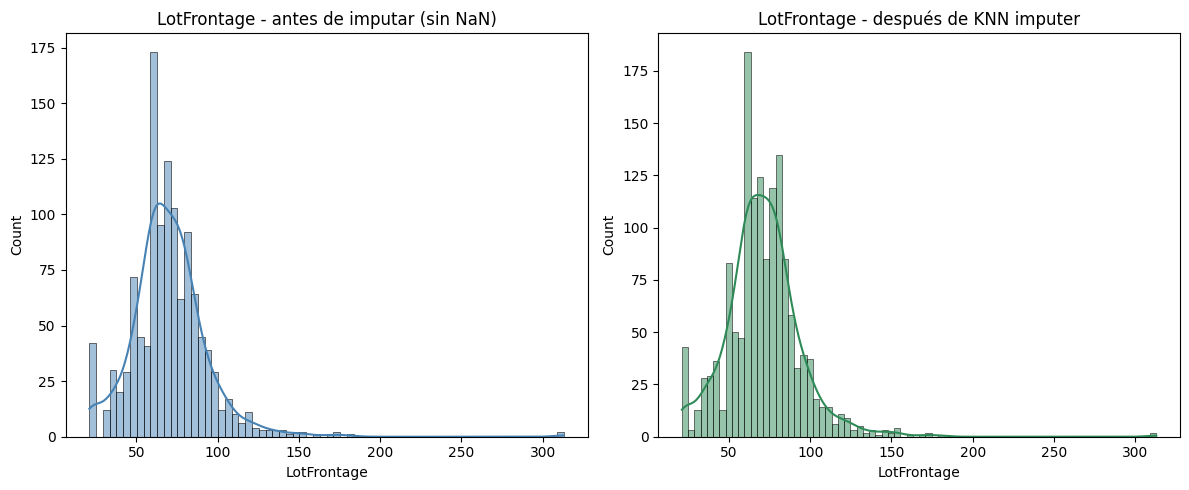

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_e['LotFrontage'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('LotFrontage - antes de imputar (sin NaN)')

sns.histplot(df['LotFrontage'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('LotFrontage - después de KNN imputer')

plt.tight_layout()
plt.show()

### Analysis 2

These variable will be filled with 0, since the analysis showed that these NaN values are not missing data in the traditional sense - they represent the structural absence of the feature

In [18]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [19]:
df_num = df.select_dtypes(exclude=["object", "category"]).copy()
cols_na_num = df_num.columns[df_num.isna().any()].tolist()

df[cols_na_num].isna().sum()

Series([], dtype: float64)

## Categorical Nan Features

In [20]:
df_cat = df.select_dtypes(include=["object","category"]).copy()

columns_na_cat = df_cat.columns[df_cat.isna().any()].tolist()

df[columns_na_cat].isna().sum()

/var/folders/gj/4kg1yfdd14588gmqty0qnncm0000gn/T/ipykernel_67690/682881582.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df.select_dtypes(include=["object","category"]).copy()


Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [21]:
for i in df[columns_na_cat].columns:
    print(df[i].value_counts(normalize=True))
    print("---"*10) 

Alley
Grvl    0.549451
Pave    0.450549
Name: proportion, dtype: float64
------------------------------
MasVnrType
BrkFace    0.756803
Stone      0.217687
BrkCmn     0.025510
Name: proportion, dtype: float64
------------------------------
BsmtQual
TA    0.456079
Gd    0.434294
Ex    0.085032
Fa    0.024596
Name: proportion, dtype: float64
------------------------------
BsmtCond
TA    0.921293
Gd    0.045678
Fa    0.031623
Po    0.001405
Name: proportion, dtype: float64
------------------------------
BsmtExposure
No    0.670183
Av    0.155415
Gd    0.094233
Mn    0.080169
Name: proportion, dtype: float64
------------------------------
BsmtFinType1
Unf    0.302178
GLQ    0.293746
ALQ    0.154603
BLQ    0.104006
Rec    0.093465
LwQ    0.052003
Name: proportion, dtype: float64
------------------------------
BsmtFinType2
Unf    0.883263
Rec    0.037975
LwQ    0.032349
BLQ    0.023207
ALQ    0.013361
GLQ    0.009845
Name: proportion, dtype: float64
------------------------------
Electrical
S

### Analysis 1

Based on the data description provided in the text file, most categorical features containing NaN values represent structural absence rather than true missing data. In these cases, the missing values indicate that the corresponding feature is not applicable for a given observation, rather than being the result of incomplete data collection.

Therefore, our approach is to replace these NaN values with "None" to explicitly represent the absence of the feature. However, two variables—MasVnrType and Electrical—require a different treatment, as their missing values do not follow this pattern and should be handled separately.

In [22]:
columns_na_cat_v2 = ['Alley',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

for col in columns_na_cat_v2:
    df[col] = df[col].fillna('None')


In [23]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [24]:
df_cat = df.select_dtypes(include=["object","category"]).copy()

columns_na_cat = df_cat.columns[df_cat.isna().any()].tolist()

df[columns_na_cat].isna().sum()

/var/folders/gj/4kg1yfdd14588gmqty0qnncm0000gn/T/ipykernel_67690/682881582.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df.select_dtypes(include=["object","category"]).copy()


Series([], dtype: float64)

# Outliers

In [25]:
df.sample(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,GarageYrBlt_flag,MasVnrArea_flag,LotFrontage_flag
287,288,20,RL,65.0,8125.0,Pave,None,IR1,Lvl,AllPub,...,None,0,6,2006,WD,Normal,88000,1,0,1
556,557,20,RL,69.0,14850.0,Pave,None,IR1,Lvl,AllPub,...,None,0,5,2006,WD,Normal,141000,0,0,0


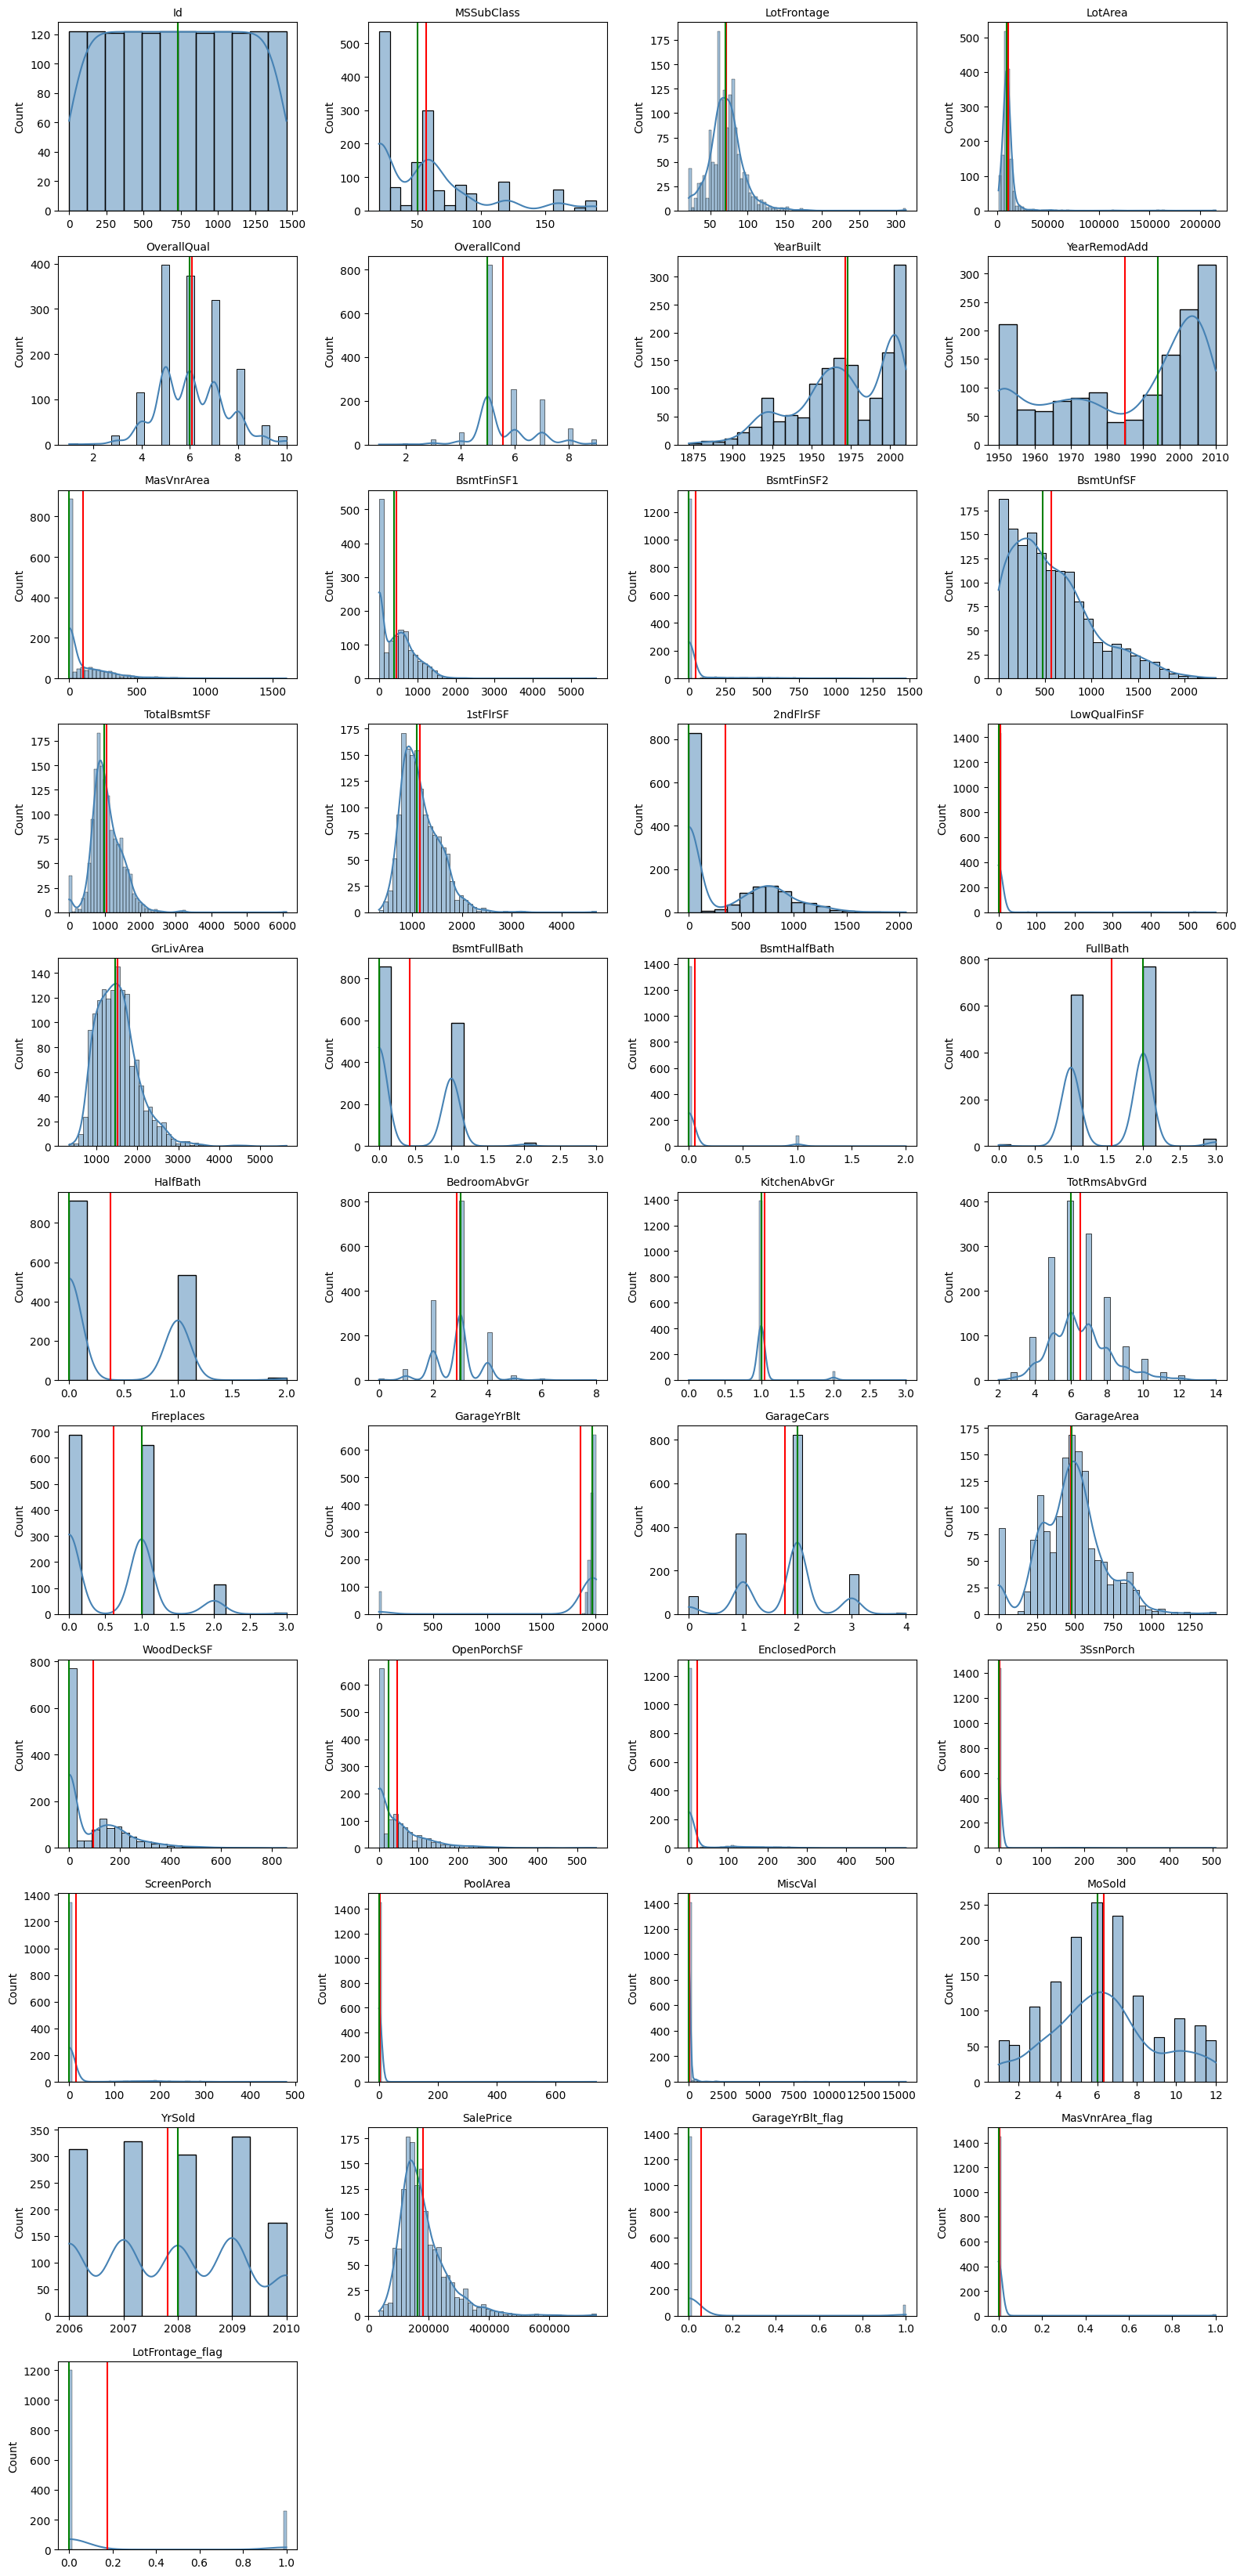

In [26]:
num_cols = df.select_dtypes(exclude=["object","category"]).columns

n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].axvline(df[col].mean(),c="r")
    axes[i].axvline(df[col].median(),c="g")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Oculta los ejes sobrantes si num_cols no llena la última fila completa
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Let's dive deep into features that can broke any pattern, for example there are cheap houses with huge area, etc...

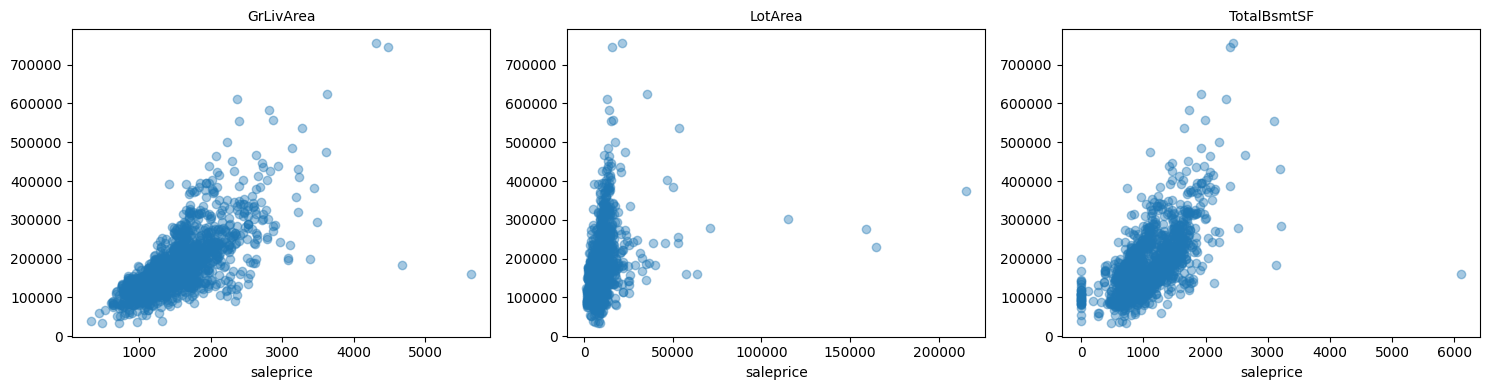

In [44]:
num_cols = ['GrLivArea', 'LotArea', 'TotalBsmtSF']

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
#axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(df[col],
                    df['SalePrice'],
                    alpha=0.4)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('saleprice')


plt.tight_layout()
plt.show()